# Анализ сервиса аренды самокатов GoFast

Вы аналитик популярного сервиса аренды самокатов GoFast. Вам передали данные о некоторых пользователях из нескольких городов, а также об их поездках. Проанализируйте данные и проверьте некоторые гипотезы, которые могут помочь бизнесу вырасти.

Чтобы совершать поездки по городу, пользователи сервиса GoFast пользуются мобильным приложением. Сервисом можно пользоваться:
* без подписки
** абонентская плата отсутствует;
** стоимость одной минуты поездки — 8 рублей;
** стоимость старта (начала поездки) — 50 рублей;
* с подпиской Ultra
** абонентская плата — 199 рублей в месяц;
** стоимость одной минуты поездки — 6 рублей;
** стоимость старта — бесплатно.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st

## Загрузка данных

In [2]:
data_u = pd.read_csv('/datasets/users_go.csv')
data_r = pd.read_csv('/datasets/rides_go.csv')
data_s = pd.read_csv('/datasets/subscriptions_go.csv')

## Предобработка данных

In [3]:
display(data_u.head())
display(data_u.info())

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB


None

In [4]:
display(data_r.head())
display(data_r.info())

,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB


None

In [5]:
display(data_s.head())
display(data_s.info())

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 192.0+ bytes


None

В ходе изучения данных не было обнаружено пропусков. Необходимо изменить формат даты в таблице поездок.

In [6]:
data_r['date'] = pd.to_datetime(data_r['date'])
print(data_r.info())

data_r['month'] = data_r['date'].dt.month
display(data_r.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   18068 non-null  int64         
 1   distance  18068 non-null  float64       
 2   duration  18068 non-null  float64       
 3   date      18068 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 564.8 KB
None


,user_id,distance,duration,date,month
0,1,4409.919140,25.599769,2021-01-01,1
1,1,2617.592153,15.816871,2021-01-18,1
2,1,754.159807,6.232113,2021-04-20,4
3,1,2694.783254,18.511000,2021-08-11,8
4,1,4028.687306,26.265803,2021-08-28,8


Добавляем новый столбец с номером месяца поездки и приводим к формату даты нужный столбец.

In [7]:
data_u_dupl = data_u.duplicated().sum()
display(data_u_dupl)

31

In [8]:
data_r_dupl = data_r.duplicated().sum()
display(data_r_dupl)

0

In [9]:
data_u = data_u.drop_duplicates().reset_index(drop = True)
data_u_dupl = data_u.duplicated().sum()
display(data_u_dupl)

0

Выявили явные дубликаты в первой таблице и сразу же их удалили, обнулив индексы.

### Вывод

Данные поступили хорошие на первый взгляд. Небольшое количество дубликатов в таблице пользователей было удалено. Столбец с датой поездки был приведен к нужному формату.
Можно начинать анализ данных.

## Исследовательский анализ данных

### Таблица пользователей

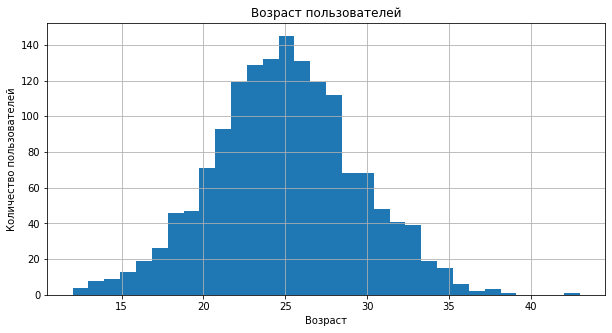

In [10]:
data_u['age'].hist(bins=32, grid=True, figsize=(10,5))
plt.title('Возраст пользователей')
plt.xlabel('Возраст')
plt.ylabel('Количество пользователей')
plt.show()

Построим гистограмму пользователей по возрастам. Видим что основная аудитория - от 21 до 28 лет. Больше всего пользователей в возрасте 25 лет.

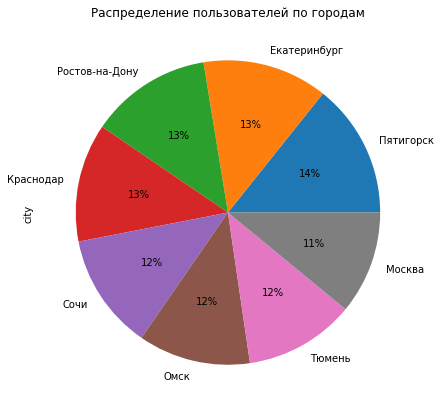

In [11]:
data_u['city'].value_counts().plot(
    kind = 'pie', 
    y = data_u['city'].value_counts(),
    autopct = '%1.0f%%',
    figsize=(7,7), 
    title = 'Распределение пользователей по городам');

Видим примерно равное количество аренд по городам, но наибольшее количество - в Пятигорске.


Text(0, 0.5, 'Количество пользователей')

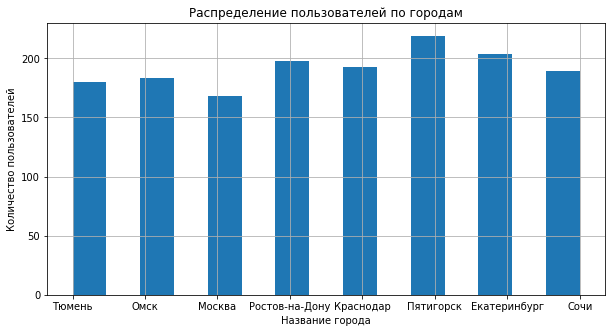

In [30]:
data_u['city'].hist(bins=15, grid=True, figsize=(10,5))
plt.title("Распределение пользователей по городам")
plt.xlabel("Название города")
plt.ylabel("Количество пользователей")

In [33]:
display(data_u['city'].value_counts())

Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168
Name: city, dtype: int64

Видим что распределение действительно достаточно равномерное, сильно выделяются от среднего лишь Пятигорск и Москва.

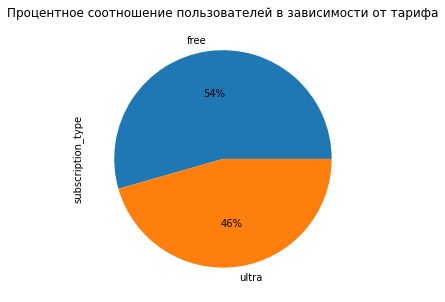

In [13]:
data_u['subscription_type'].value_counts().plot(
    kind = 'pie', 
    y = data_u['subscription_type'].value_counts(), 
    autopct = '%1.0f%%', 
    figsize=(5,5),
    title = 'Процентное соотношение пользователей в зависимости от тарифа');

Видим что пользователей без подписки больше, но отличие от количества пользователей с подпиской невелико.

### Таблица поездок

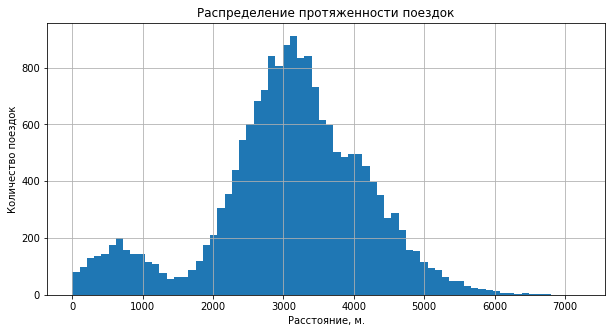

In [14]:
data_r['distance'].hist(bins=70, grid=True, figsize=(10,5))
plt.title("Распределение протяженности поездок")
plt.xlabel("Расстояние, м.")
plt.ylabel("Количество поездок")
plt.show()

На гистограмме видим два пика длины поездок. Первый, небольшой, пик на 600-700 метрах. Второй, абсолютный, пик на 3200 метрах и около этого расстояния.

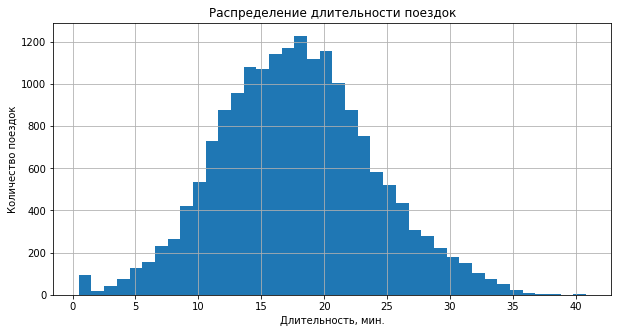

In [15]:
data_r['duration'].hist(bins=40, grid=True, figsize=(10,5))
plt.title("Распределение длительности поездок")
plt.xlabel("Длительность, мин.")
plt.ylabel("Количество поездок")
plt.show()

Видим основной пик графика на 14-21 минутах поездки, а также небольшой выброс в районе 0 - скорее всего это пользователи которые оформили аренду по ошибке.

### Вывод

Минимальный возраст пользователей - **12 лет**, самый пожилой возраст пользователей - **43 года**. Основная возрастная категория - **21-28 лет**.

Распределение пользователей по городам достаточно однородное, небольшое лидерство держит Пятигорск - **14%**. Наименьшее количество пользователей в Москве - **11%**

Пользователей пользующихся бесплатно больше - **54%**, однако это значение не имеет подавляющего преимущества.

В основном пользователи арендуют самокаты чтобы преодолеть небольшое расстояние (до **1 км**) или чтобы преодолеть примерно **3 км**.

Продолжительность поездок ведет себя более равномерно чем преодоленное расстояние. Основной пик приходится на **14-21 минуту**, и основное количество поездок в него попадает.

## Объединение данных

In [16]:
data = data_u.merge(data_r)
data = data.merge(data_s)
data['duration'] = np.ceil(data['duration']) 
display(data)
display(data_r.count())

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,26.0,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,16.0,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,7.0,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,19.0,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,27.0,2021-08-28,8,6,0,199
...,...,...,...,...,...,...,...,...,...,...,...,...
18063,1534,Альберт,25,Краснодар,free,3781.098080,20.0,2021-11-04,11,8,50,0
18064,1534,Альберт,25,Краснодар,free,2840.423057,22.0,2021-11-16,11,8,50,0
18065,1534,Альберт,25,Краснодар,free,3826.185507,19.0,2021-11-18,11,8,50,0
18066,1534,Альберт,25,Краснодар,free,2902.308661,17.0,2021-11-27,11,8,50,0


user_id     18068
distance    18068
duration    18068
date        18068
month       18068
dtype: int64

Объединили таблицы с поездками и пользователями, проверку количества строк провели по второму датафрейму - количество совпало, значит данные не потерялись.

In [17]:
data_ultra = data[data['subscription_type'] == 'ultra']
data_free = data[data['subscription_type'] == 'free']
display(data_ultra, data_free)

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,26.0,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,16.0,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,7.0,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,19.0,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,27.0,2021-08-28,8,6,0,199
...,...,...,...,...,...,...,...,...,...,...,...,...
6495,699,Оксана,22,Москва,ultra,3973.046497,25.0,2021-08-29,8,6,0,199
6496,699,Оксана,22,Москва,ultra,3288.702563,16.0,2021-09-12,9,6,0,199
6497,699,Оксана,22,Москва,ultra,3076.159348,15.0,2021-09-26,9,6,0,199
6498,699,Оксана,22,Москва,ultra,4707.845501,16.0,2021-10-17,10,6,0,199


,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
6500,700,Айдар,22,Омск,free,2515.690719,15.0,2021-01-02,1,8,50,0
6501,700,Айдар,22,Омск,free,846.932642,17.0,2021-02-01,2,8,50,0
6502,700,Айдар,22,Омск,free,4004.434142,21.0,2021-02-04,2,8,50,0
6503,700,Айдар,22,Омск,free,1205.911290,10.0,2021-02-10,2,8,50,0
6504,700,Айдар,22,Омск,free,3047.379435,18.0,2021-02-14,2,8,50,0
...,...,...,...,...,...,...,...,...,...,...,...,...
18063,1534,Альберт,25,Краснодар,free,3781.098080,20.0,2021-11-04,11,8,50,0
18064,1534,Альберт,25,Краснодар,free,2840.423057,22.0,2021-11-16,11,8,50,0
18065,1534,Альберт,25,Краснодар,free,3826.185507,19.0,2021-11-18,11,8,50,0
18066,1534,Альберт,25,Краснодар,free,2902.308661,17.0,2021-11-27,11,8,50,0


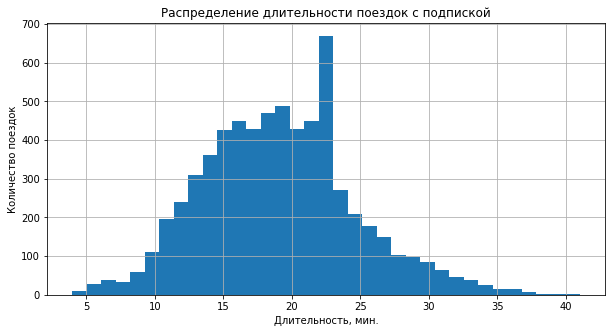

In [18]:
data_ultra['duration'].hist(bins=35, grid=True, figsize=(10,5))
plt.title("Распределение длительности поездок с подпиской")
plt.xlabel("Длительность, мин.")
plt.ylabel("Количество поездок")
plt.show()

In [36]:
data_ultra['duration'].describe()

count    6500.000000
mean       19.037692
std         5.577439
min         4.000000
25%        15.000000
50%        19.000000
75%        22.000000
max        41.000000
Name: duration, dtype: float64

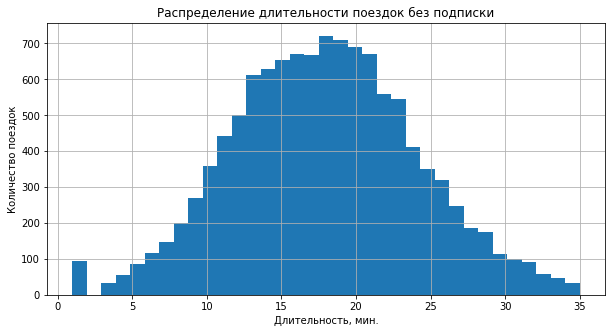

In [19]:
data_free['duration'].hist(bins=35, grid=True, figsize=(10,5))
plt.title("Распределение длительности поездок без подписки")
plt.xlabel("Длительность, мин.")
plt.ylabel("Количество поездок")
plt.show()

In [37]:
data_free['duration'].describe()

count    11568.000000
mean        17.890992
std          6.330250
min          1.000000
25%         13.000000
50%         18.000000
75%         22.000000
max         35.000000
Name: duration, dtype: float64

В целом мы видим нормальное распределение, однако стоит отметить что пользователи без подписки распределены более равномерно.
Пользователи с подпиской в среднем ездят от 15 до 22 минут, а бесплатные пользователи от 13 до 22. Также стоит отметить что минимальное время аренды с подпиской составляет 4 минуты, что означает что ошибочных "моментальных" аренд в данной выборке нет.

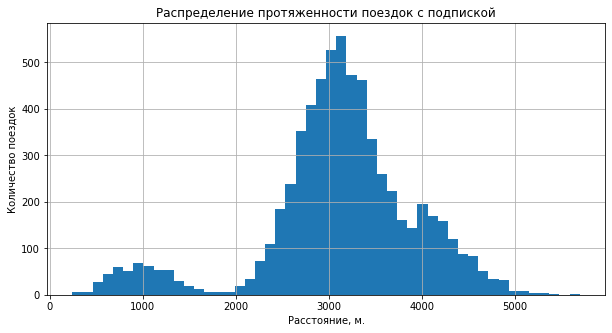

In [20]:
data_ultra['distance'].hist(bins=50, grid=True, figsize=(10,5))
plt.title("Распределение протяженности поездок с подпиской")
plt.xlabel("Расстояние, м.")
plt.ylabel("Количество поездок")
plt.show()

In [38]:
data_ultra['distance'].describe()

count    6500.000000
mean     3115.445388
std       836.895330
min       244.210438
25%      2785.444017
50%      3148.637229
75%      3560.574425
max      5699.769662
Name: distance, dtype: float64

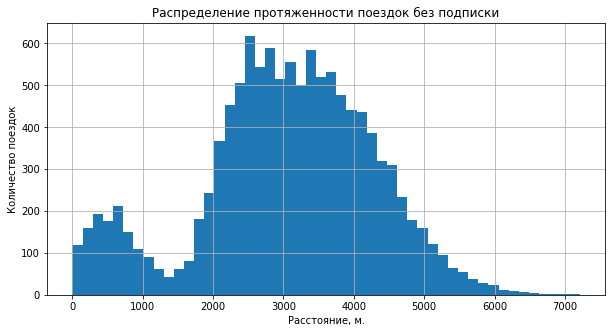

In [21]:
data_free['distance'].hist(bins=50, grid=True, figsize=(10,5))
plt.title("Распределение протяженности поездок без подписки")
plt.xlabel("Расстояние, м.")
plt.ylabel("Количество поездок")
plt.show()

In [39]:
data_free['distance'].describe()

count    11568.000000
mean      3045.495282
std       1246.173806
min          0.855683
25%       2366.562689
50%       3114.648465
75%       3905.697894
max       7211.007745
Name: distance, dtype: float64

Пользователи с подпиской в основном катаются на расстояние примерно от 2785 до 3560 метров. Пользователи без подписки распределены также более равномерно и катаются на расстояния от 2366 до 3905 метров.

### Вывод

Данные о пользователях и поездках были объеденены в один датафрейм, также были созданы отдельные датафреймы по платным и бесплатным пользователям.

На основе имеющихся данных можно предположить что пользователи с подпиской чаще ездят одним постоянным маршрутом (исходя из очень явного пика длины поездки), в то время как разброс дальности поездок бесплатных пользователей гораздо шире и он достаточно равномерно распределен.

## Подсчёт выручки

In [43]:
total_data = data.pivot_table(index=['user_id', 'month'], values = ['distance', 'duration', 'name', 'subscription_type'], aggfunc={'distance':'sum', 'duration':'sum', 'name':'count', 'subscription_type': 'min'})
total_data.columns = ['total_distance', 'total_duration', 'trip_count', 'subscription_type']
display(total_data)

total_distance  total_duration  trip_count subscription_type
user_id month                                                              
1       1         7027.511294            42.0           2             ultra
        4          754.159807             7.0           1             ultra
        8         6723.470560            46.0           2             ultra
        10        5809.911100            32.0           2             ultra
        11        7003.499363            56.0           3             ultra
...                       ...             ...         ...               ...
1534    6         3409.468534            26.0           2              free
        8         7622.453034            48.0           2              free
        9         4928.173852            23.0           1              free
        11       13350.015305            78.0           4              free
        12        2371.711192            16.0           1              free

[11331 rows x 4 columns]

Нашли суммарное расстояние, количество поездок и их длительность для каждого пользователя.

In [44]:
income_data = total_data.merge(data_s , on = 'subscription_type')

def income(row):
    if row['subscription_type'] == 'ultra':
        return row['minute_price'] * row['total_duration'] + 199
    elif row['subscription_type'] == 'free':
        return row['minute_price'] * row['total_duration'] + row['start_ride_price'] * row['trip_count']
    else:
        return 0

In [46]:
income_data['revenue_per_month'] = income_data.apply(income, axis=1)
display(income_data)

,total_distance,total_duration,trip_count,subscription_type,minute_price,start_ride_price,subscription_fee,revenue_per_month
0,7027.511294,42.0,2,ultra,6,0,199,451.0
1,754.159807,7.0,1,ultra,6,0,199,241.0
2,6723.470560,46.0,2,ultra,6,0,199,475.0
3,5809.911100,32.0,2,ultra,6,0,199,391.0
4,7003.499363,56.0,3,ultra,6,0,199,535.0
...,...,...,...,...,...,...,...,...
11326,3409.468534,26.0,2,free,8,50,0,308.0
11327,7622.453034,48.0,2,free,8,50,0,484.0
11328,4928.173852,23.0,1,free,8,50,0,234.0
11329,13350.015305,78.0,4,free,8,50,0,824.0


### Вывод

Создали новый датафрейм с агрегированными данными по каждому пользователю. Помимо этого добавили новый столбец с помесячной выручкой по каждому пользователю.

## Шаг 6. Проверка гипотез

### Важно понять, тратят ли пользователи с подпиской больше времени на поездки?

Нулевая гипогтеза - пользователи с подпиской и без тратят одинаковое время на поездки.

Альтернативная гипотеза - пользователи с подпиской тратят на поездки больше времени, чем пользователи без подписки.

In [25]:
duration_ultra = data_ultra['duration']
duration_free = data_free['duration']
alpha = 0.05
results = st.ttest_ind(duration_ultra, duration_free, alternative = 'greater')
print('p-значение:', results.pvalue)
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не удалось отвергнуть нулевую гипотезу') 
print('Среднее время поездки пользователей с подпиской:', data_ultra['duration'].mean())
print('Среднее время поездки пользователей без подписки:', data_free['duration'].mean())

p-значение: 2.4959453720736625e-34
Отвергаем нулевую гипотезу
Среднее время поездки пользователей с подпиской: 19.037692307692307
Среднее время поездки пользователей без подписки: 17.890992392807746


Пользователи с подпиской совершают более длительные поездки в среднем. Отвергаем нулевую гипотезу.

### Можно ли сказать, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров? 

Нулевая гипотеза - пользователи с подпиской проезжают не более 3130 метров за одну поездку.

Альтернативная гипотеза - пользователи с подпиской проезжают больше 3130 метров за одну поездку в среднем.

In [26]:
null_value = 3130
alpha = 0.05
results = st.ttest_1samp(data_ultra['distance'], null_value, alternative = 'greater')
print('p-value:', results.pvalue)
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не удалось отвергнуть нулевую гипотезу')

p-value: 0.9195368847849785
Не удалось отвергнуть нулевую гипотезу


Пользователи с подпиской в среднем проезжают менее 3130 метров, нулевая гипотеза подтверждена.

Можно предположить что, учитывая то что подписка убирает стартовую цену на поездку, с подпиской менее длительные поездки становятся гораздо выгоднее, чем кататься на бесплатном тарифе.

### Проверьте гипотезу о том, будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки. 

Нулевая гипотеза - пользователи с подпиской и без приносят одинаковый доход.

Альтернативная гипотеза - пользователи с подпиской приносят больший доход, чем пользователи без подписки.

In [27]:
income_ultra = total_data[total_data['subscription_type'] == 'ultra']
income_free = total_data[total_data['subscription_type'] == 'free']

ultra = income_ultra['revenue_per_month']
free = income_free['revenue_per_month']
alpha = 0.05
results = st.ttest_ind(ultra, free, alternative = 'greater')
print('p-значение:', results.pvalue)
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу') 
print('Средняя выручка от пользователей с подпиской:', income_ultra['revenue_per_month'].mean())
print('Средняя выручка от пользователей без подписки:', income_free['revenue_per_month'].mean())

p-значение: 1.8850394384715216e-31
Отвергаем нулевую гипотезу
Средняя выручка от пользователей с подпиской: 362.7921906022502
Средняя выручка от пользователей без подписки: 328.6413651073845


Выручка от пользователей с подпиской выше чем от бесплатных пользователей.

### Представьте такую ситуацию: техническая команда сервиса обновила сервера, с которыми взаимодействует мобильное приложение. Она надеется, что из-за этого количество обращений в техподдержку значимо снизилось. Некоторый файл содержит для каждого пользователя данные о количестве обращений до обновления и после него. Какой тест вам понадобился бы для проверки этой гипотезы?

В данном случае думаю что нам нужно будет принять нулевую гипотезу -
*Количество обращений от пользователей с подпиской и без равно.*

Альтернативная гипотеза - количество обращений после обновления  снизилось

Проверять ее будем по такой же схеме как и гипотезы выше, используя метод *st.ttest_rel()*

## Общий вывод

В данной работе были проанализированы данные о сервисе самокатов GoFast.

Были загружены три датафрейма с данными о пользователях, их поездках и о подписке. Была проведена про предварительной проверке качества данных и исправлению небольших недочетов.

Был проведен анализ данных, в результате которого было выявлено что:

* Количество пользователей по городам распределено достаточно равномерно, **с небольшими выбросами в Москве и Петрозаводске**.
* Пользователей пользующихся приложением без подписки больше, но не сильно отличается от пользователей с подпиской (**54% и 46% соответственно**).
* Основная возрастная группа пользователей - **21-28 лет**.
* В среднем пользователи проезжают **от 2,5 до 4 километров** за поездку.
* В среднем длительность поездки составляет **14-21 минут**.

Был создан единый датафрейм с данными о пользователях и их поездках, а также разделил его на пользователей с подпиской и без.

В заключении были проверены гипотезы:
* Пользователи с подпиской и без тратят одинаковое время на поездки. **Гипотеза была отвергнута**
* Пользователи с подпиской проезжают не более 3130 метров за одну поездку. **Гипотеза была подтверждена**
* Пользователи с подпиской и без приносят одинаковый доход. **Гипотеза была отвергнута**